<a href="https://colab.research.google.com/github/Ahnaf-17/AI_powered_personal_finance_advisor/blob/main/COIT29224_Assessment1_Shakir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install tensorflow scikit-learn matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 770.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 123.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 93.4 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print("All libraries imported successfully")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully
TensorFlow version: 2.21.0


In [21]:
file_path = "/content/mango_nir.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Shape of dataset:", df.shape)
df.head()

Dataset loaded successfully
Shape of dataset: (12011, 137)


,Set,Data Type,DM,600,603,606,609,612,615,618,...,972,975,978,981,984,987,990,993,996,999
0,Cal,Training,16.792506,-0.169368,-0.190148,-0.204675,-0.217446,-0.227716,-0.236586,-0.244903,...,-0.276466,-0.275833,-0.277469,-0.279087,-0.281585,-0.286274,-0.291861,-0.298373,-0.305885,-0.313134
1,Cal,Training,16.792506,-0.166110,-0.186150,-0.201401,-0.213795,-0.224327,-0.233436,-0.241646,...,-0.273691,-0.272281,-0.273021,-0.275661,-0.277798,-0.282546,-0.287625,-0.294656,-0.302313,-0.309441
2,Cal,Training,16.070979,-0.374045,-0.373929,-0.372734,-0.370380,-0.367333,-0.363919,-0.360659,...,-0.270683,-0.270807,-0.272077,-0.273772,-0.277118,-0.280703,-0.286242,-0.292599,-0.299298,-0.307015
3,Cal,Training,16.070979,-0.374003,-0.374057,-0.372836,-0.370513,-0.367361,-0.363990,-0.360882,...,-0.272173,-0.269741,-0.270569,-0.273172,-0.276150,-0.280397,-0.286027,-0.292482,-0.299262,-0.306500
4,Cal,Training,16.394013,-0.159916,-0.163426,-0.163453,-0.160791,-0.156160,-0.150573,-0.145092,...,-0.276646,-0.274851,-0.276203,-0.277353,-0.279749,-0.284363,-0.290519,-0.296981,-0.303737,-0.311447


In [23]:
print(df.columns.tolist())

['Set', 'Data Type', 'DM', '600', '603', '606', '609', '612', '615', '618', '621', '624', '627', '630', '633', '636', '639', '642', '645', '648', '651', '654', '657', '660', '663', '666', '669', '672', '675', '678', '681', '684', '687', '690', '693', '696', '699', '702', '705', '708', '711', '714', '717', '720', '723', '726', '729', '732', '735', '738', '741', '744', '747', '750', '753', '756', '759', '762', '765', '768', '771', '774', '777', '780', '783', '786', '789', '792', '795', '798', '801', '804', '807', '810', '813', '816', '819', '822', '825', '828', '831', '834', '837', '840', '843', '846', '849', '852', '855', '858', '861', '864', '867', '870', '873', '876', '879', '882', '885', '888', '891', '894', '897', '900', '903', '906', '909', '912', '915', '918', '921', '924', '927', '930', '933', '936', '939', '942', '945', '948', '951', '954', '957', '960', '963', '966', '969', '972', '975', '978', '981', '984', '987', '990', '993', '996', '999']


In [24]:
print("Set column values:")
print(df["Set"].value_counts())

print("\nData Type column values:")
print(df["Data Type"].value_counts())

Set column values:
Set
Cal          7413
Tuning       2830
Val Ext      1448
Val Ext 2     320
Name: count, dtype: int64

Data Type column values:
Data Type
Training    7413
Valid       2830
Test        1768
Name: count, dtype: int64


In [25]:
spectral_cols = [col for col in df.columns if col not in ["Set", "Data Type", "DM"]]

print("Number of spectral columns:", len(spectral_cols))
print("First 10 spectral columns:", spectral_cols[:10])
print("Last 10 spectral columns:", spectral_cols[-10:])

Number of spectral columns: 134
First 10 spectral columns: ['600', '603', '606', '609', '612', '615', '618', '621', '624', '627']
Last 10 spectral columns: ['972', '975', '978', '981', '984', '987', '990', '993', '996', '999']


In [10]:
train_df = df[df["Data Type"] == "Training"].copy()
val_df = df[df["Data Type"] == "Valid"].copy()
test_df = df[df["Data Type"] == "Test"].copy()

print("Training rows:", train_df.shape)
print("Validation rows:", val_df.shape)
print("Test rows:", test_df.shape)

Training rows: (7413, 137)
Validation rows: (2830, 137)
Test rows: (1768, 137)


In [27]:
train_df = df[df["Data Type"] == "Training"].copy()
val_df = df[df["Data Type"] == "Valid"].copy()
test_df = df[df["Data Type"] == "Test"].copy()

print("Training set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (7413, 137)
Validation set shape: (2830, 137)
Test set shape: (1768, 137)


In [28]:
X_train = train_df[spectral_cols].values.astype("float32")
y_train = train_df["DM"].values.astype("float32")

X_val = val_df[spectral_cols].values.astype("float32")
y_val = val_df["DM"].values.astype("float32")

X_test = test_df[spectral_cols].values.astype("float32")
y_test = test_df["DM"].values.astype("float32")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (7413, 134)
y_train: (7413,)
X_val: (2830, 134)
y_val: (2830,)
X_test: (1768, 134)
y_test: (1768,)


In [29]:
#Standardise the data
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

train_std[train_std == 0] = 1.0

X_train_scaled = (X_train - train_mean) / train_std
X_val_scaled = (X_val - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

print("Scaling complete")
print("Scaled training shape:", X_train_scaled.shape)

Scaling complete
Scaled training shape: (7413, 134)


In [30]:
#Reshape for 1D-CNN

X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_val_cnn = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("Train CNN shape:", X_train_cnn.shape)
print("Validation CNN shape:", X_val_cnn.shape)
print("Test CNN shape:", X_test_cnn.shape)

Train CNN shape: (7413, 134, 1)
Validation CNN shape: (2830, 134, 1)
Test CNN shape: (1768, 134, 1)


In [31]:
#Build the 1D-CNN model

tf.keras.utils.set_random_seed(42)

model = Sequential([
    Input(shape=(X_train_cnn.shape[1], 1)),

    Conv1D(
        filters=1,
        kernel_size=21,
        strides=1,
        activation="elu",
        kernel_initializer="he_normal",
        kernel_regularizer=l2(1e-4)
    ),

    Flatten(),

    Dense(36, activation="elu", kernel_initializer="he_normal", kernel_regularizer=l2(1e-4)),
    Dense(18, activation="elu", kernel_initializer="he_normal", kernel_regularizer=l2(1e-4)),
    Dense(12, activation="elu", kernel_initializer="he_normal", kernel_regularizer=l2(1e-4)),

    Dense(1, activation="linear")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 114, 1)         │            22 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 114)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 36)             │         4,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │           666 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           228 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,069 (19.80 KB)

 Trainable params: 5,069 (19.80 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
#Add training helpers

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=30,
    min_delta=1e-5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=15,
    min_delta=1e-6,
    verbose=1
)

print("Callbacks ready")

Callbacks ready


In [33]:
#Train the model

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=200,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 46.2481 - mae: 5.1101 - val_loss: 11.5393 - val_mae: 2.5507 - learning_rate: 0.0050
Epoch 2/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.5765 - mae: 2.2964 - val_loss: 5.9226 - val_mae: 1.9272 - learning_rate: 0.0050
Epoch 3/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2287 - mae: 2.0000 - val_loss: 4.1895 - val_mae: 1.6467 - learning_rate: 0.0050
Epoch 4/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.3810 - mae: 1.8580 - val_loss: 4.4710 - val_mae: 1.7141 - learning_rate: 0.0050
Epoch 5/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.9455 - mae: 1.7899 - val_loss: 4.2716 - val_mae: 1.6780 - learning_rate: 0.0050
Epoch 6/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.5643 - mae: 1.7216 - val_loss: 4.2650 - val_mae: 1.6752 - learning_rate: 0.0050
Epoch 7/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.1033 - mae: 1.6279 - val_loss: 4.1247 - val_mae: 1.6331 - learning_rate: 0.0050
Epoch 8/200

In [34]:
# Predict

y_val_pred = model.predict(X_val_cnn).flatten()
y_test_pred = model.predict(X_test_cnn).flatten()

print("Prediction complete")

89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step
Prediction complete


In [36]:
#Calculate RMSE and R^2

val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Validation RMSE:", round(val_rmse, 4))
print("Validation R2:", round(val_r2, 4))
print("Test RMSE:", round(test_rmse, 4))
print("Test R2:", round(test_r2, 4))

Validation RMSE: 0.8574
Validation R2: 0.8366
Test RMSE: 1.3245
Test R2: 0.7254


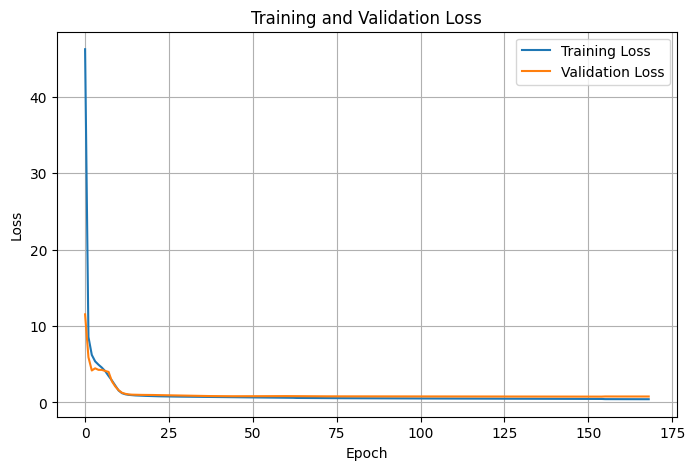

In [37]:
#Loss curve

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

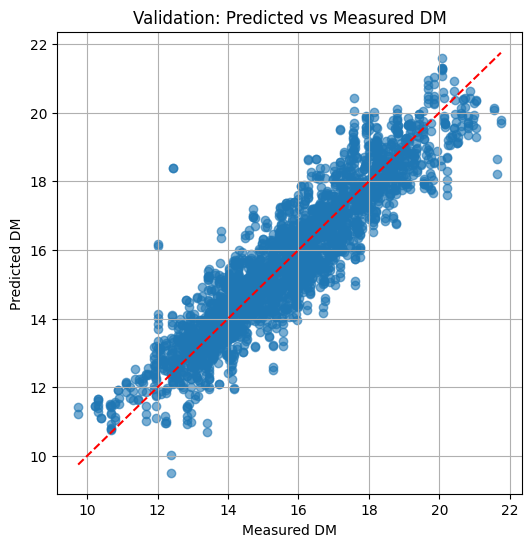

In [38]:
#Validation predicted vs measured

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.title("Validation: Predicted vs Measured DM")
plt.xlabel("Measured DM")
plt.ylabel("Predicted DM")
plt.grid(True)
plt.show()

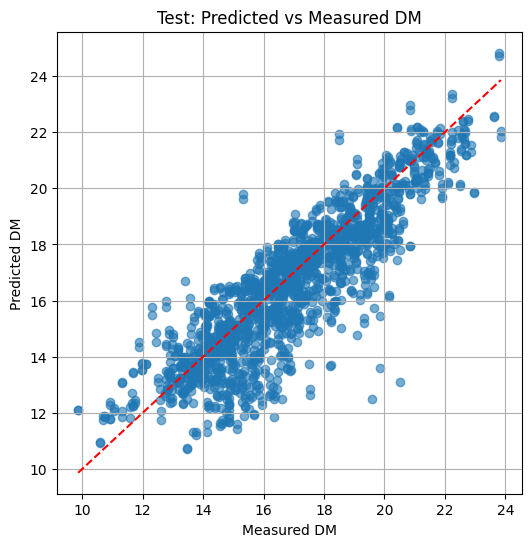

In [39]:
#Test predicted vs measured

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Test: Predicted vs Measured DM")
plt.xlabel("Measured DM")
plt.ylabel("Predicted DM")
plt.grid(True)
plt.show()

In [40]:
#Save predictions

results_df = pd.DataFrame({
    "Measured_DM": y_test,
    "Predicted_DM": y_test_pred
})

results_df.to_csv("cnn_test_predictions.csv", index=False)
print("Saved as cnn_test_predictions.csv")

Saved as cnn_test_predictions.csv
